### 4번문제: 연령대별로 선호하는 영화 장르가 다를까? (난이도: 중)
**📘 문제**

- 한 영화관에서 고객의 **연령대(20대, 30대, 40대)**에 따라 선호하는 **영화 장르(액션, 로맨스)**에 차이가 있는지 궁금해졌습니다.

- 이를 알아보기 위해 300명의 고객을 대상으로 설문조사를 진행하여 분할표를 얻었습니다.

- 이번 실습에서는 **카이제곱 독립성 검정(Chi-squared Test of Independence)**으로
  두 범주형 변수 사이에 연관성이 있는지 검증합니다.

- 또한 **"두 변수가 서로 아무 관련이 없다면(독립이라면)"** 어떤 카이제곱 통계량들이 나올 수 있는지 시뮬레이션으로 확인해 봅니다.

In [5]:
# 구글 코랩 환경에서 한글 폰트 설치 및 설정하기
# 필요시 아래 코드 실행 후, [런타임] - [세션 다시 시작] 후 셀을 다시 실행하세요.
!pip install statsmodels
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

# 파이썬 라이브러리 및 모듈 가져오기
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'  # 기본 폰트 설정
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지

Sudo가 이 컴퓨터에서 사용하지 않도록 설정되어 있습니다. 사용하도록 설정하려면 으로 이동하세요. ]8;;ms-settings:developers\Developer Settings page]8;;\ 설정 앱의
Sudo가 이 컴퓨터에서 사용하지 않도록 설정되어 있습니다. 사용하도록 설정하려면 으로 이동하세요. ]8;;ms-settings:developers\Developer Settings page]8;;\ 설정 앱의
'rm'��(��) ���� �Ǵ� �ܺ� ����, ������ �� �ִ� ���α׷�, �Ǵ�
��ġ ������ �ƴմϴ�.


관측 빈도 (Observed Frequencies):
     액션  로맨스
20대  70   30
30대  50   60
40대  30   60


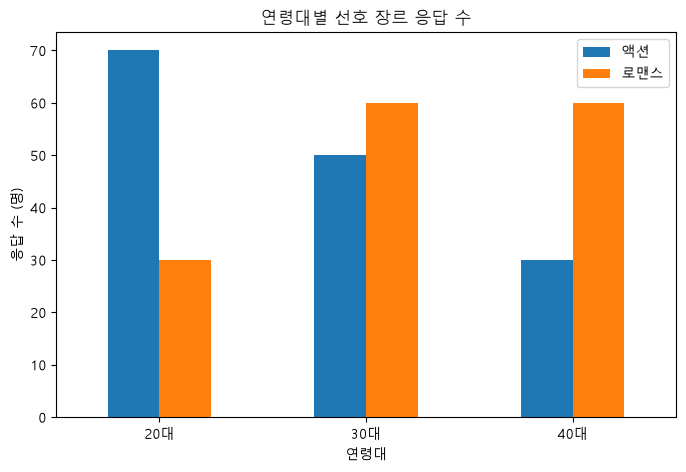

In [6]:
# 데이터 생성 (관측 빈도 분할표)
data = {'액션': [70, 50, 30],
        '로맨스': [30, 60, 60]}
observed = pd.DataFrame(data, index=['20대', '30대', '40대'])

print("관측 빈도 (Observed Frequencies):")
print(observed)

# 분할표 시각화
observed.plot(kind='bar', figsize=(8, 5))
plt.title("연령대별 선호 장르 응답 수")
plt.xlabel("연령대")
plt.ylabel("응답 수 (명)")
plt.xticks(rotation=0)
plt.show()

**📌 아래를 수행해 보세요:**

- 귀무가설(H₀)과 대립가설(H₁)을 세워 봅시다.

- 카이제곱 독립성 검정을 수행하여 카이제곱 통계량, p-값, 자유도, **기대 빈도**를 구해봅시다.

- **"연령대와 선호 장르가 독립이라면"** 어떤 분할표들이 나타날 수 있는지 5,000번 시뮬레이션해 봅시다.

- 시뮬레이션으로 얻은 카이제곱 통계량 분포와 실제 관찰된 카이제곱 통계량을 비교해 봅시다.

In [ ]:
# [문제 4] Q1. 귀무가설(H₀)과 대립가설(H₁)을 주석으로 작성해봅시다.
# H₀ (귀무가설): 연령대와 선호 장르는 서로 독립이다 (관련이 없다).
# H₁ (대립가설): 연령대와 선호 장르는 서로 독립이 아니다 (관련이 있다).

In [7]:
# [문제 4] Q2. 카이제곱 독립성 검정을 수행하고 카이제곱 통계량, p-값, 자유도, 기대 빈도를 구해봅시다.
# 기대 빈도는 관측 빈도와 비교하기 쉽도록 데이터프레임 형태로 출력해보세요.
chi2_stat, p_value, dof, expected = stats.chi2_contingency(observed)

expected_df = pd.DataFrame(expected, index=observed.index, columns=observed.columns)

print("=== 관측 빈도 ===")
print(observed)
print("\n=== 기대 빈도 (독립일 때 기대되는 값) ===")
print(expected_df.round(2))

print(f"\n카이제곱 통계량: {chi2_stat:.4f}")
print(f"자유도: {dof}")
print(f"p-value: {p_value:.8f}")

alpha = 0.05
if p_value < alpha:
    print(f"\np-value({p_value:.8f}) < 유의수준({alpha}) → 귀무가설 기각")
    print("→ 연령대와 선호 장르는 서로 독립이 아니다 (연관이 있다).")
else:
    print(f"\np-value({p_value:.8f}) >= 유의수준({alpha}) → 귀무가설 기각 못함")
    print("→ 연령대와 선호 장르가 독립이 아니라고 볼 증거가 부족하다.")

=== 관측 빈도 ===
     액션  로맨스
20대  70   30
30대  50   60
40대  30   60

=== 기대 빈도 (독립일 때 기대되는 값) ===
       액션   로맨스
20대  50.0  50.0
30대  55.0  55.0
40대  45.0  45.0

카이제곱 통계량: 26.9091
자유도: 2
p-value: 0.00000143

p-value(0.00000143) < 유의수준(0.05) → 귀무가설 기각
→ 연령대와 선호 장르는 서로 독립이 아니다 (연관이 있다).


In [4]:
# [문제 4] Q3. H₀가 사실(두 변수가 독립)이라고 가정하고 시뮬레이션을 5,000번 수행해봅시다.
# 각 반복마다 300명의 가상 고객에게 연령대와 장르를 '독립적으로' 할당한 후,
# 가상 분할표를 만들고 카이제곱 통계량을 계산하여 리스트에 저장해보세요.
# 힌트 1: 전체 비율(observed.sum(axis=0) / 전체, observed.sum(axis=1) / 전체)을 확률로 사용
# 힌트 2: np.random.choice 로 300명의 연령대와 장르를 각각 독립적으로 생성
# 힌트 3: pd.crosstab 으로 분할표 생성 후 stats.chi2_contingency 로 통계량 계산
np.random.seed(2026)
n_simulations = 5000
n_total = observed.values.sum()  # 300명

# 힌트1: 전체 비율 (주변확률) 계산
age_groups = observed.index.tolist()      # ['20대', '30대', '40대']
genres = observed.columns.tolist()        # ['액션', '로맨스']

age_probs = (observed.sum(axis=1) / n_total).values     # 연령대별 비율
genre_probs = (observed.sum(axis=0) / n_total).values   # 장르별 비율

simulated_chi2 = []

for _ in range(n_simulations):
    # 힌트2: 독립적으로(서로 무관하게) 300명의 연령대와 장르를 각각 뽑기
    fake_ages = np.random.choice(age_groups, size=n_total, p=age_probs)
    fake_genres = np.random.choice(genres, size=n_total, p=genre_probs)

    # 힌트3: 분할표 생성 후 카이제곱 통계량 계산
    fake_table = pd.crosstab(fake_ages, fake_genres)
    fake_chi2, _, _, _ = stats.chi2_contingency(fake_table)
    simulated_chi2.append(fake_chi2)

simulated_chi2 = np.array(simulated_chi2)

In [ ]:
# [문제 4] Q4. 시뮬레이션으로 얻은 카이제곱 통계량의 분포를 히스토그램으로 그려봅시다.
# 실제 관찰된 카이제곱 통계량을 세로선으로 함께 표시해 봅시다.
plt.figure(figsize=(10, 6))
sns.histplot(simulated_chi2, bins=50, kde=True)
plt.axvline(x=chi2_stat, color='red', linestyle='--', linewidth=2,
            label=f'실제 관찰된 카이제곱 통계량: {chi2_stat:.2f}')
plt.title(f'H0(연령대와 장르가 독립)가 참일 때, 카이제곱 통계량의 분포 (시뮬레이션 {n_simulations}회)')
plt.xlabel('카이제곱 통계량')
plt.ylabel('빈도')
plt.legend()
plt.show()

In [ ]:
# 기각역 계산 (카이제곱 검정은 오른쪽 꼬리 단측검정)
alpha = 0.05
critical_value = stats.chi2.ppf(1 - alpha, dof)
print(f"임계값(critical value, dof={dof}): {critical_value:.4f}")

# 기각역 오른쪽 끝 = 시뮬레이션 최댓값과 관찰값 중 더 큰 쪽 기준
x_max = max(simulated_chi2.max(), chi2_stat) * 1.1

plt.figure(figsize=(10, 6))
sns.histplot(simulated_chi2, bins=50, kde=True)

# 기각역 음영 표시 (임계값보다 큰 오른쪽 영역)
plt.axvspan(critical_value, x_max, color='red', alpha=0.15,
            label=f'기각역 (χ² ≥ {critical_value:.2f})')

# 임계값 경계선
plt.axvline(x=critical_value, color='darkred', linestyle=':', linewidth=2)

# 관찰된 카이제곱 통계량
plt.axvline(x=chi2_stat, color='red', linestyle='--', linewidth=2,
            label=f'실제 관찰된 카이제곱 통계량: {chi2_stat:.2f}')

plt.title(f'H0(연령대와 장르가 독립)가 참일 때, 카이제곱 통계량의 분포 (시뮬레이션 {n_simulations}회)')
plt.xlabel('카이제곱 통계량')
plt.ylabel('빈도')
plt.legend()
plt.show()

print(f"\n관찰된 카이제곱 통계량({chi2_stat:.4f})이 기각역 안에 "
      f"{'속함' if chi2_stat >= critical_value else '속하지 않음'}")

**🧠 데이터를 어떻게 읽을까요?**

- '기대 빈도'는 어떤 의미를 가지며, '관측 빈도'와의 차이가 클수록 카이제곱 통계량은 어떻게 변할까요? -> 두 변수가 독립이라는 가정 하에 나올 이론적인 빈도수 , 클수록 카이제곱 통계량은 커진다. 

- Q4의 히스토그램은 어떤 분포를 시각화한 것인가요? 실제 관찰된 카이제곱 통계량(세로선)은 흔한 값인가요, 극단적인 값인가요? -> 카이제곱분포를 시각화했다. 독립이라는 가정 아래에서는 흔하지 않은 값, 즉 극단적인 값이다. 

- 유의수준 0.05에서, 연령대와 선호 장르 사이에 통계적으로 유의미한 연관성이 있다고 결론 내릴 수 있나요? 그 이유는 무엇인가요? -> 연관성이 있다. p가 너무 작잖아ㅏ

- 이 결과를 바탕으로 영화관은 연령대별로 어떤 상영 전략이나 프로모션을 세울 수 있을까요?

[1번 문제]
- 기대 빈도는 "만약 연령대와 선호 장르가 정말 서로 독립(아무 관련 없음)이라면, 이론적으로 나와야 할 빈도"를 뜻한다. 예를 들어 20대-액션 칸의 기대 빈도(50.0)는, 전체 액션/로맨스 비율과 연령대 비율만 가지고 계산한 "우연히 예상되는 값"이다.

- 관측 빈도(실제 데이터)와 기대 빈도(독립 가정 시 이론값)의 차이가 클수록, 카이제곱 통계량은 커진다. 카이제곱 통계량 자체가 (관측-기대)²/기대 값들을 모두 더한 것이기 때문에, 두 값의 괴리가 클수록 "독립이라는 가정과 실제 데이터가 안 맞는다"는 신호가 강해지는 것이다.

[2번 문제]
- 이 히스토그램은 "연령대와 선호 장르가 독립이다"라는 귀무가설이 참이라고 가정했을 때, 300명을 무작위로 반복 추출하여(5000번 반복) 나올 수 있는 카이제곱 통계량들의 분포(카이제곱 분포에 대한 시뮬레이션 근사)를 나타낸다.

- 실제 관찰된 카이제곱 통계량(26.91)은 매우 극단적인 값이다. 분포 대부분이 0~10 사이에 몰려 있는데, 관찰값은 그 범위를 훨씬 벗어난 오른쪽 끝에 위치해 있다. 즉 두 변수가 독립이라면 이런 값이 나오는 건 거의 불가능에 가깝다.

- 그래프에서 색칠이 오른쪽에만 있는 이유: 카이제곱 통계량은 (관측-기대)²을 더하는 구조라 항상 0 이상이고, 값이 클수록 "독립 가정과 실제 데이터가 안 맞는다"는 뜻이다. 즉 통계량이 작으면 작을수록 독립 가정과 잘 맞는 거고, 크면 클수록 독립 가정에서 벗어난 증거가 된다 — 방향이 한쪽(큰 값 쪽)으로만 존재하는 것이다. 그래서 왼쪽 꼬리는 애초에 "기각할 이유"가 되지 않고, 기각역은 오른쪽 꼬리 하나만 있는 단측검정 구조가 되는 것이다.

[3번 문제]
- 있다. p-value(0.00000143)가 유의수준 0.05보다 훨씬 작기 때문에 귀무가설(독립이다)을 기각한다. 즉 연령대와 선호 장르 사이에는 우연이라고 보기 어려운, 통계적으로 유의미한 연관성이 존재한다.

[4번 문제]
- 관측 빈도를 보면 20대는 액션(70명)을 로맨스(30명)보다 훨씬 선호하고, 40대는 반대로 로맨스(60명)를 액션(30명)보다 선호하는 뚜렷한 경향이 있다. 30대는 두 장르 선호도가 비슷하다(50 vs 60).

- 이를 바탕으로 영화관은 연령대 타겟 마케팅을 할 수 있다. 예를 들어 액션 영화 개봉 시 20대가 몰리는 시간대(저녁·주말 등)을 분석하여 20대 대상 프로모션(학생 할인, SNS 이벤트 등)을 집중하고, 로맨스 영화 개봉 시에는 40대 대상 프로모션을 강화하는 식으로 상영관 배정과 광고 채널을 세분화할 수 있다.